# Data Exploration

This notebook explores the structure and basic characteristics of the dataset used for text classification.

Goals:
- Inspect dataset schema
- Analyze class distribution
- Examine text properties
- Identify potential preprocessing issues

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
dataset = load_dataset("ag_news")

df = dataset["train"].to_pandas()

df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.info()

Shape: (120000, 2)

Columns: ['text', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


In [4]:
df["label"].value_counts()

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

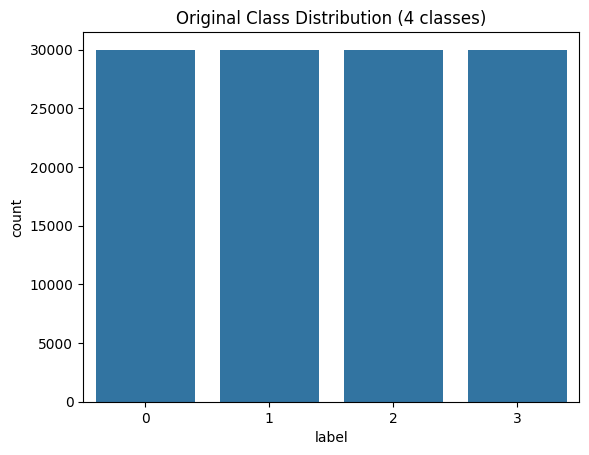

In [5]:
sns.countplot(x="label", data=df)
plt.title("Original Class Distribution (4 classes)")
plt.show()

In [6]:
# Binary mapping
df["label_binary"] = df["label"].apply(lambda x: 0 if x < 2 else 1)

df["label_binary"].value_counts()

label_binary
1    60000
0    60000
Name: count, dtype: int64

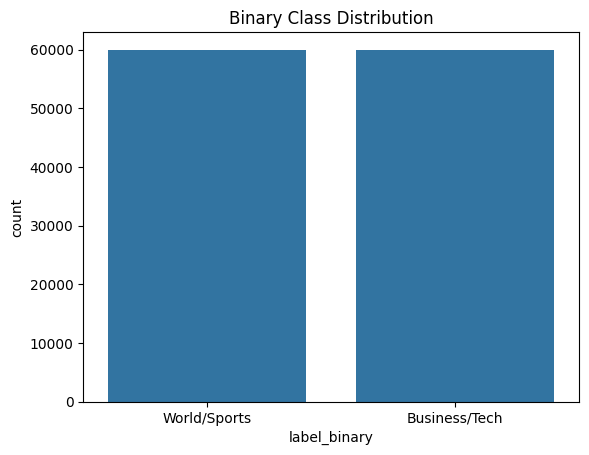

In [7]:
sns.countplot(x="label_binary", data=df)
plt.title("Binary Class Distribution")
plt.xticks([0, 1], ["World/Sports", "Business/Tech"])
plt.show()

In [8]:
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

df["text_length"].describe()

count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64

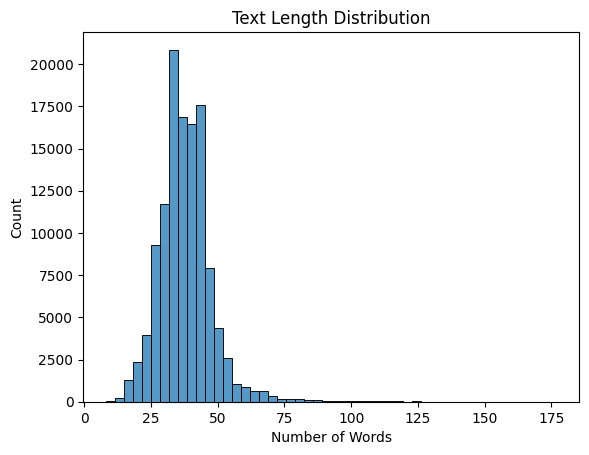

In [9]:
sns.histplot(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

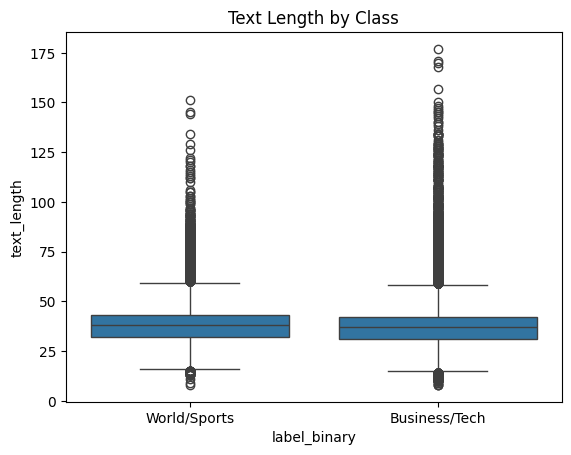

In [10]:
sns.boxplot(x="label_binary", y="text_length", data=df)
plt.title("Text Length by Class")
plt.xticks([0, 1], ["World/Sports", "Business/Tech"])
plt.show()

In [11]:
print("=== Class 0 Example ===")
print(df[df["label_binary"] == 0]["text"].iloc[0][:500])

print("\n=== Class 1 Example ===")
print(df[df["label_binary"] == 1]["text"].iloc[0][:500])

=== Class 0 Example ===
Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Keller were faster than the teenager in the 200 free preliminaries.

=== Class 1 Example ===
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [13]:
vectorizer = CountVectorizer(max_features=20, stop_words="english")

X = vectorizer.fit_transform(df["text"])

words = vectorizer.get_feature_names_out()
counts = np.asarray(X.sum(axis=0)).flatten()

word_freq = pd.DataFrame({"word": words, "count": counts})
word_freq = word_freq.sort_values(by="count", ascending=False)

word_freq

,word,count
0,39,44506
8,new,21427
12,said,20267
11,reuters,19340
1,ap,16276
4,gt,13231
6,lt,13182
17,year,9772
10,quot,9596
16,world,8632


## Observations

- The dataset is balanced after binary conversion.
- Text lengths are relatively consistent across classes.
- Vocabulary differs significantly between classes, suggesting that TF-IDF features may perform well.
- This dataset represents topic classification, which is expected to be easier than political bias detection.

These observations guide the choice of feature engineering methods used in later experiments.